In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error

In [38]:
df = pd.read_csv(r"C:\Users\nandi\Documents\ML_CO2_ER\data\df_viscosity_clean.csv")

In [39]:
print(df['solvent_ID'].nunique())
print(df['smiles'].nunique())

2503
2496


In [40]:
def canonicalize_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None
    return None

In [5]:
df['smiles_can'] = df['smiles'].apply(canonicalize_smiles)

[13:25:16] Explicit valence for atom # 3 N, 4, is greater than permitted
[13:25:16] Explicit valence for atom # 4 N, 4, is greater than permitted


In [6]:
df['smiles'].value_counts()

smiles
O1C[C@@H]2[C@H](C1)O2            3
C[C@H]1C[C@H](C)CN(C1)C          2
C[C@H]1CCCCO1                    2
CC(=C)[C@H]1CO1                  2
C[C@H]1C[C@H](C)OC(=O)O1         2
                                ..
CCOCCN[C@H](C1CCCC1)C            1
C1CC[C@H]2[C@@H](C1)COC2         1
CCCCCN[C@H](COC)C                1
CCN(CC[C@@H](C(C)C)N)CC          1
COC[C@H](N[C@H](CC(F)(F)F)C)C    1
Name: count, Length: 2496, dtype: int64

In [7]:
df['smiles_can'].dropna(inplace=True)

In [8]:
df.head()

,solvent_ID,smiles,Binding_Energy_eV,solubility_CO2 [mol/L],viscosity [Pa s],nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,...,homo_lumo_gap_eV,polarizability_ang3,min_partial_charge,max_partial_charge,min_abs_partial_charge,max_abs_partial_charge,vib_freq_min_cm1,vib_freq_max_cm1,vib_freq_count,smiles_can
0,zinc_5593217,COCCNC(=O)[C@@H](CC)C,-0.246414,0.097848,0.011764,0.0,0.0,12.906117,2.122425,4.244850,...,181.930993,748.130500,-0.832151,0.392923,0.034817,0.832151,23.0414,3627.7857,78.0,CC[C@@H](C)C(=O)NCCOC
1,zinc_400210175,CO[C@H](C1CC1)CN1CCCCC1,-0.239933,0.117575,0.007448,0.0,1.0,17.343700,2.348592,4.557405,...,161.701629,933.997796,-1.140739,0.562172,0.001836,1.140739,28.8558,3225.7980,96.0,CO[C@@H](CN1CCCCC1)C1CC1
2,zinc_5696920,NOCCN(C)C,-0.219656,0.097619,0.002281,0.0,1.0,7.727407,1.931852,3.863703,...,168.343554,496.654099,-0.802413,0.379028,0.149089,0.802413,52.1440,3517.7383,51.0,CN(C)CCON
3,zinc_685002938,C[C@@H](CN(CC1CC1)CC(F)F)O,-0.325154,0.088216,0.025603,0.0,1.0,14.943352,2.294945,4.451333,...,171.357226,807.127445,-0.794729,0.647513,0.076133,0.794729,26.9357,3729.3970,84.0,C[C@H](O)CN(CC(F)F)CC1CC1
4,zinc_52602135,CNC[C@@H](C(C)C)OC,-0.288984,0.131763,0.001110,0.0,1.0,10.199109,2.119166,4.238332,...,167.803019,655.958528,-0.847175,0.397601,0.172656,0.847175,62.5690,3522.0361,72.0,CNC[C@H](OC)C(C)C


In [9]:
print(df['solvent_ID'].nunique())
print(df['smiles'].nunique())

2503
2496


In [10]:
df_clean = df.dropna(subset=['viscosity [Pa s]']).copy()

In [11]:
df_clean = df_clean[df_clean["viscosity [Pa s]"] < 0.035]

In [12]:
print(f"Dataset merged! New shape: {df_clean.shape}")

Dataset merged! New shape: (2477, 1421)


In [13]:
# Define Features (X) and Target (y)
target_col = 'viscosity [Pa s]'
exclude_cols = ['smiles', 'smiles_can', 'solvent_ID', 'IP_values', 'scaffold', 'solubility_CO2 [mol/L]', 'viscosity [Pa s]', 'Binding_Energy_eV']
X_cols = [c for c in df_clean.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df_clean[c])]

In [14]:
X = df_clean[X_cols]
y = df_clean[target_col]
y_log = np.log1p(y)

<Axes: ylabel='viscosity [Pa s]'>

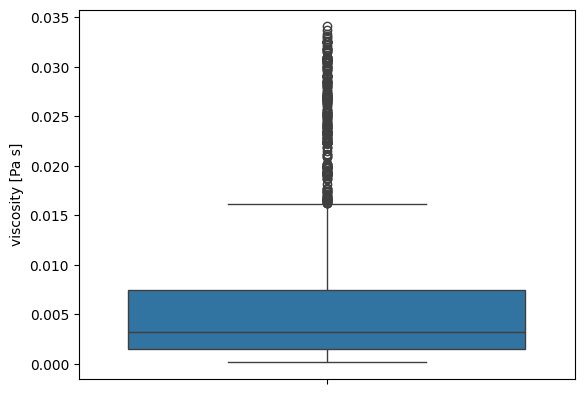

In [15]:
import seaborn as sns
sns.boxplot(y_log)

In [16]:
# Create Scaffold (OOD) Split

def get_scaffold(s):
    try:
        mol = Chem.MolFromSmiles(s)
        if mol: return MurckoScaffold.MurckoScaffoldSmiles(mol=mol)
    except: return None
    return None

In [17]:
df_clean['scaffold'] = df_clean['smiles_can'].apply(get_scaffold)
scaffold_counts = df_clean['scaffold'].value_counts()
unique_scaffolds = scaffold_counts.index.tolist()
unique_scaffolds

['',
 'C1CC1',
 'C1CCC1',
 'C1CCNC1',
 'C1CCNCC1',
 'C1COCCN1',
 'C1CCCC1',
 'C1CNC1',
 'C1CCOC1',
 'C1COC1',
 'C1CCCCC1',
 'C1COCO1',
 'C1CO1',
 'C1CCOCC1',
 'O=C1OCCO1',
 'C1CN(CC2CC2)CCO1',
 'C1NCC2CC12',
 'C1CN1',
 'C1CCCNCC1',
 'O=C1OCCCO1',
 'C1CCCCCC1',
 'C1CN(CC2CC2)C1',
 'C1CC1CC1CC1',
 'C1CC1NC1COC1',
 'O=C1COCO1',
 'C1COCOC1',
 'C1CCN(CC2CC2)C1',
 'C1=CCCC1',
 'C1CC(NCC2CC2)C1',
 'C1CCC(N2CCOCC2)C1',
 'O=C1CCCO1',
 'C1CC(C2CC2)CN1',
 'C1CC2CC2CN1',
 'C=C1COC(=O)O1',
 'C1CC2CCC1N2',
 'C1OCC2OC12',
 'C1CC(CN2CCOCC2)C1',
 'C1CNCCN1',
 'C1CC(CNC2CCC2)C1',
 'C=C1CCNCC1',
 'C1CCCNCCC1',
 'C1CCN(CC2CO2)CC1',
 'C1CC2(C1)CO2',
 'C1CCC2NCC2C1',
 'C1CCN(CCOC2CC2)C1',
 'C1CCC(N2CCOCC2)CC1',
 'C1CCCCCCC1',
 'C1CCN(CC2CC2)CC1',
 'C1CC2OC2C1',
 'C1CC12CNC2',
 'C1CCC(NC2CC2)C1',
 'C1CC(NCC2CC2)CO1',
 'C1CCN(CCC2CC2)C1',
 'C=C1CCOC1',
 'C1CC1C1CO1',
 'C1CC(CN2CCCC2)C1',
 'C1CC(NC2CCOC2)C1',
 'O=C1CCOC1',
 'C1CC(NC2CCC2)C1',
 'C1CCN(C2CCCC2)CC1',
 'C1CCC2COCC2C1',
 'C1CCN(CCC2CC2)CC1',
 'C1CC

In [18]:
len(unique_scaffolds)

136

In [19]:
scaffold_counts

scaffold
                    1185
C1CC1                240
C1CCC1               148
C1CCNC1              143
C1CCNCC1              82
                    ... 
C1CC2CNC(C1)C2         1
C1CC2CCC(C1)O2         1
C1CC1CN1CC2CC2C1       1
C=C1COCC1=C            1
C1CCN(C2CCOC2)C1       1
Name: count, Length: 136, dtype: int64

In [20]:
# Put common scaffolds in Train (80%), rare/distinct ones in Test (20%)
train_scaffolds = []
train_count = 0
total_count = len(df_clean)

for sc in unique_scaffolds:
    if train_count + scaffold_counts[sc] <= total_count * 0.8:
        train_scaffolds.append(sc)
        train_count += scaffold_counts[sc]

train_mask = df_clean['scaffold'].isin(train_scaffolds)
test_mask = ~train_mask

In [21]:
print(len(train_mask[train_mask == True]))
print(len(test_mask[test_mask == True]))

1981
496


In [22]:
X_train_ood, X_test_ood = X[train_mask], X[test_mask]
y_train_ood, y_test_ood = y_log[train_mask], y_log[test_mask]

# Create Random Split for comparison
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
xgb = XGBRegressor(
    tree_method='hist',  # key line for GPU
    device='cuda', 
    random_state=42
)
param_dist = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [3, 6, 8, 10],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_lambda': [0.1, 0.5, 1, 5]
}


# from xgboost import XGBRegressor
# model = XGBRegressor(
#     #tree_method='gpu_hist',
#     tree_method='hist',
#     #device='cuda',
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_lambda=10,
#     learning_rate=0.01,
#     n_estimators=500,
#     max_depth=6,
#     random_state=42
# )

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),       # Handle NaNs strictly
    ('var_thresh', VarianceThreshold(threshold=0)),      # Drop constant cols
    ('scaler', StandardScaler()),                        # Normalize (Optional for RF, but good for Feature Sel)
    ('selector', SelectKBest(f_regression, k=150)),       # Strict feature selection
    ('model', xgb)                                      # Your optimized RF
])
# pipeline_rand = Pipeline([
#     ('imputer', SimpleImputer(strategy='median')),       # Handle NaNs strictly
#     ('var_thresh', VarianceThreshold(threshold=0)),      # Drop constant cols
#     ('scaler', StandardScaler()),                        # Normalize (Optional for RF, but good for Feature Sel)
#     # ('selector', SelectKBest(f_regression, k=20)),       # Strict feature selection
#     ('model', best_model_rand)                                  # Your optimized RF
# ])

search_ood = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=1  # must be 1 when using GPU with XGBoost
)
search_rand = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring='neg_mean_squared_error',
    cv=10,
    verbose=1,
    n_jobs=1  # must be 1 when using GPU with XGBoost
)

In [28]:
# search_ood = RandomizedSearchCV(pipeline, param_distributions=param_dist)
# search_rand = RandomizedSearchCV(pipeline, param_distributions=param_dist)

In [29]:
print("\n--- Tuning & Training OOD Split ---")
search_ood.fit(X_train_ood, y_train_ood)
best_ood = search_ood.best_estimator_
print(f"Best OOD Params: {search_ood.best_params_}")
y_pred_ood = best_ood.predict(X_test_ood)
stats_ood = (r2_score(y_test_ood, y_pred_ood), mean_absolute_error(y_test_ood, y_pred_ood))


--- Tuning & Training OOD Split ---
Fitting 10 folds for each of 30 candidates, totalling 300 fits
Best OOD Params: {'model__subsample': 0.8, 'model__reg_lambda': 0.1, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.6}


In [30]:
stats_ood

(0.5303451677706217, 0.0023530532194831096)

In [31]:
print("Training Random Split...")
search_rand.fit(X_train_rand, y_train_rand)
best_rand = search_rand.best_estimator_
y_pred_rand = best_rand.predict(X_test_rand)
stats_rand = (r2_score(y_test_rand, y_pred_rand), mean_absolute_error(y_test_rand, y_pred_rand))
stats_rand

Training Random Split...
Fitting 10 folds for each of 30 candidates, totalling 300 fits


(0.9112903040013499, 0.0011251840683957027)

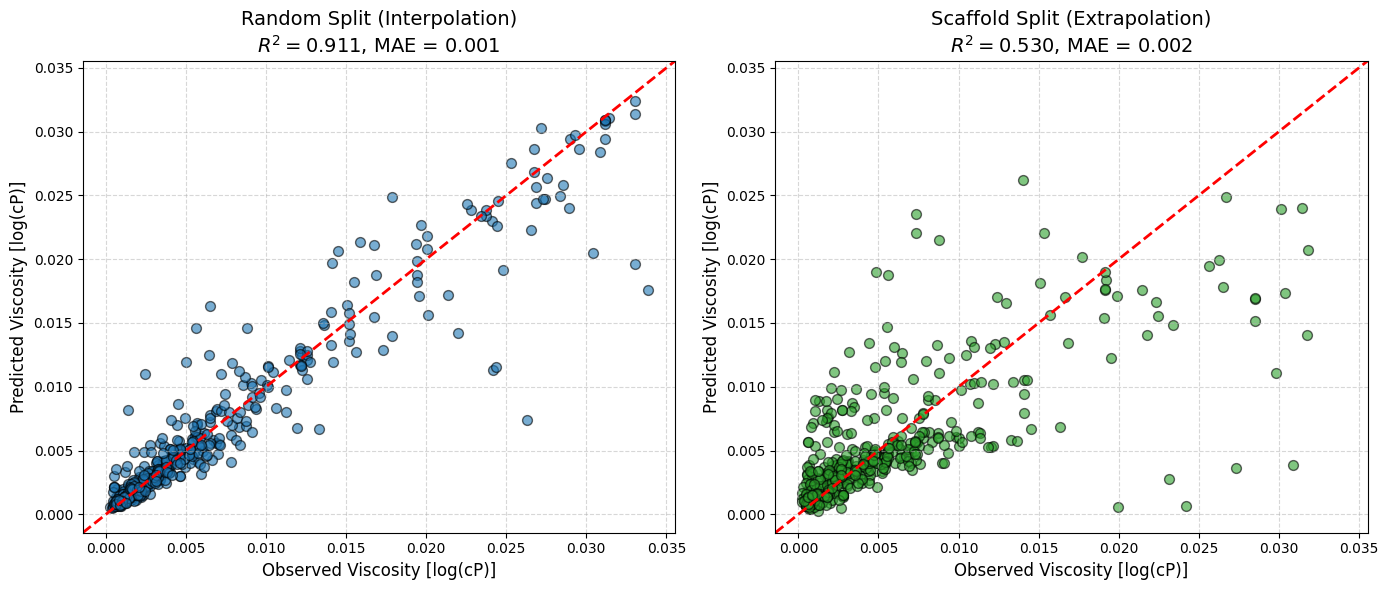

OOD R2: 0.530
Random R2: 0.911


In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Unified axis limits
all_vals = np.concatenate([y_test_rand, y_pred_rand, y_test_ood, y_pred_ood])
min_val, max_val = np.min(all_vals), np.max(all_vals)
pad = (max_val - min_val) * 0.05
lims = [min_val - pad, max_val + pad]

# Plot Random Split
axes[0].scatter(y_test_rand, y_pred_rand, alpha=0.6, c='#1f77b4', edgecolors='k', s=50)
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
axes[0].set_title(f"Random Split (Interpolation)\n$R^2 = {stats_rand[0]:.3f}$, MAE = {stats_rand[1]:.3f}", fontsize=14)
axes[0].set_xlabel("Observed Viscosity [log(cP)]", fontsize=12)
axes[0].set_ylabel("Predicted Viscosity [log(cP)]", fontsize=12)
axes[0].set_xlim(lims)
axes[0].set_ylim(lims)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot OOD Split
axes[1].scatter(y_test_ood, y_pred_ood, alpha=0.6, c='#2ca02c', edgecolors='k', s=50)
axes[1].plot(lims, lims, 'r--', lw=2)
axes[1].set_title(f"Scaffold Split (Extrapolation)\n$R^2 = {stats_ood[0]:.3f}$, MAE = {stats_ood[1]:.3f}", fontsize=14)
axes[1].set_xlabel("Observed Viscosity [log(cP)]", fontsize=12)
axes[1].set_ylabel("Predicted Viscosity [log(cP)]", fontsize=12)
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('Visc_XFB_OOD_Validation.png', dpi=300)
plt.show()

print(f"OOD R2: {stats_ood[0]:.3f}")
print(f"Random R2: {stats_rand[0]:.3f}")

C:\Users\nandi\AppData\Local\Temp\ipykernel_20380\3770488949.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([y_test_ood.min(), y_test_ood.max()], [y_test_ood.min(), y_test_ood.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_20380\3770488949.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


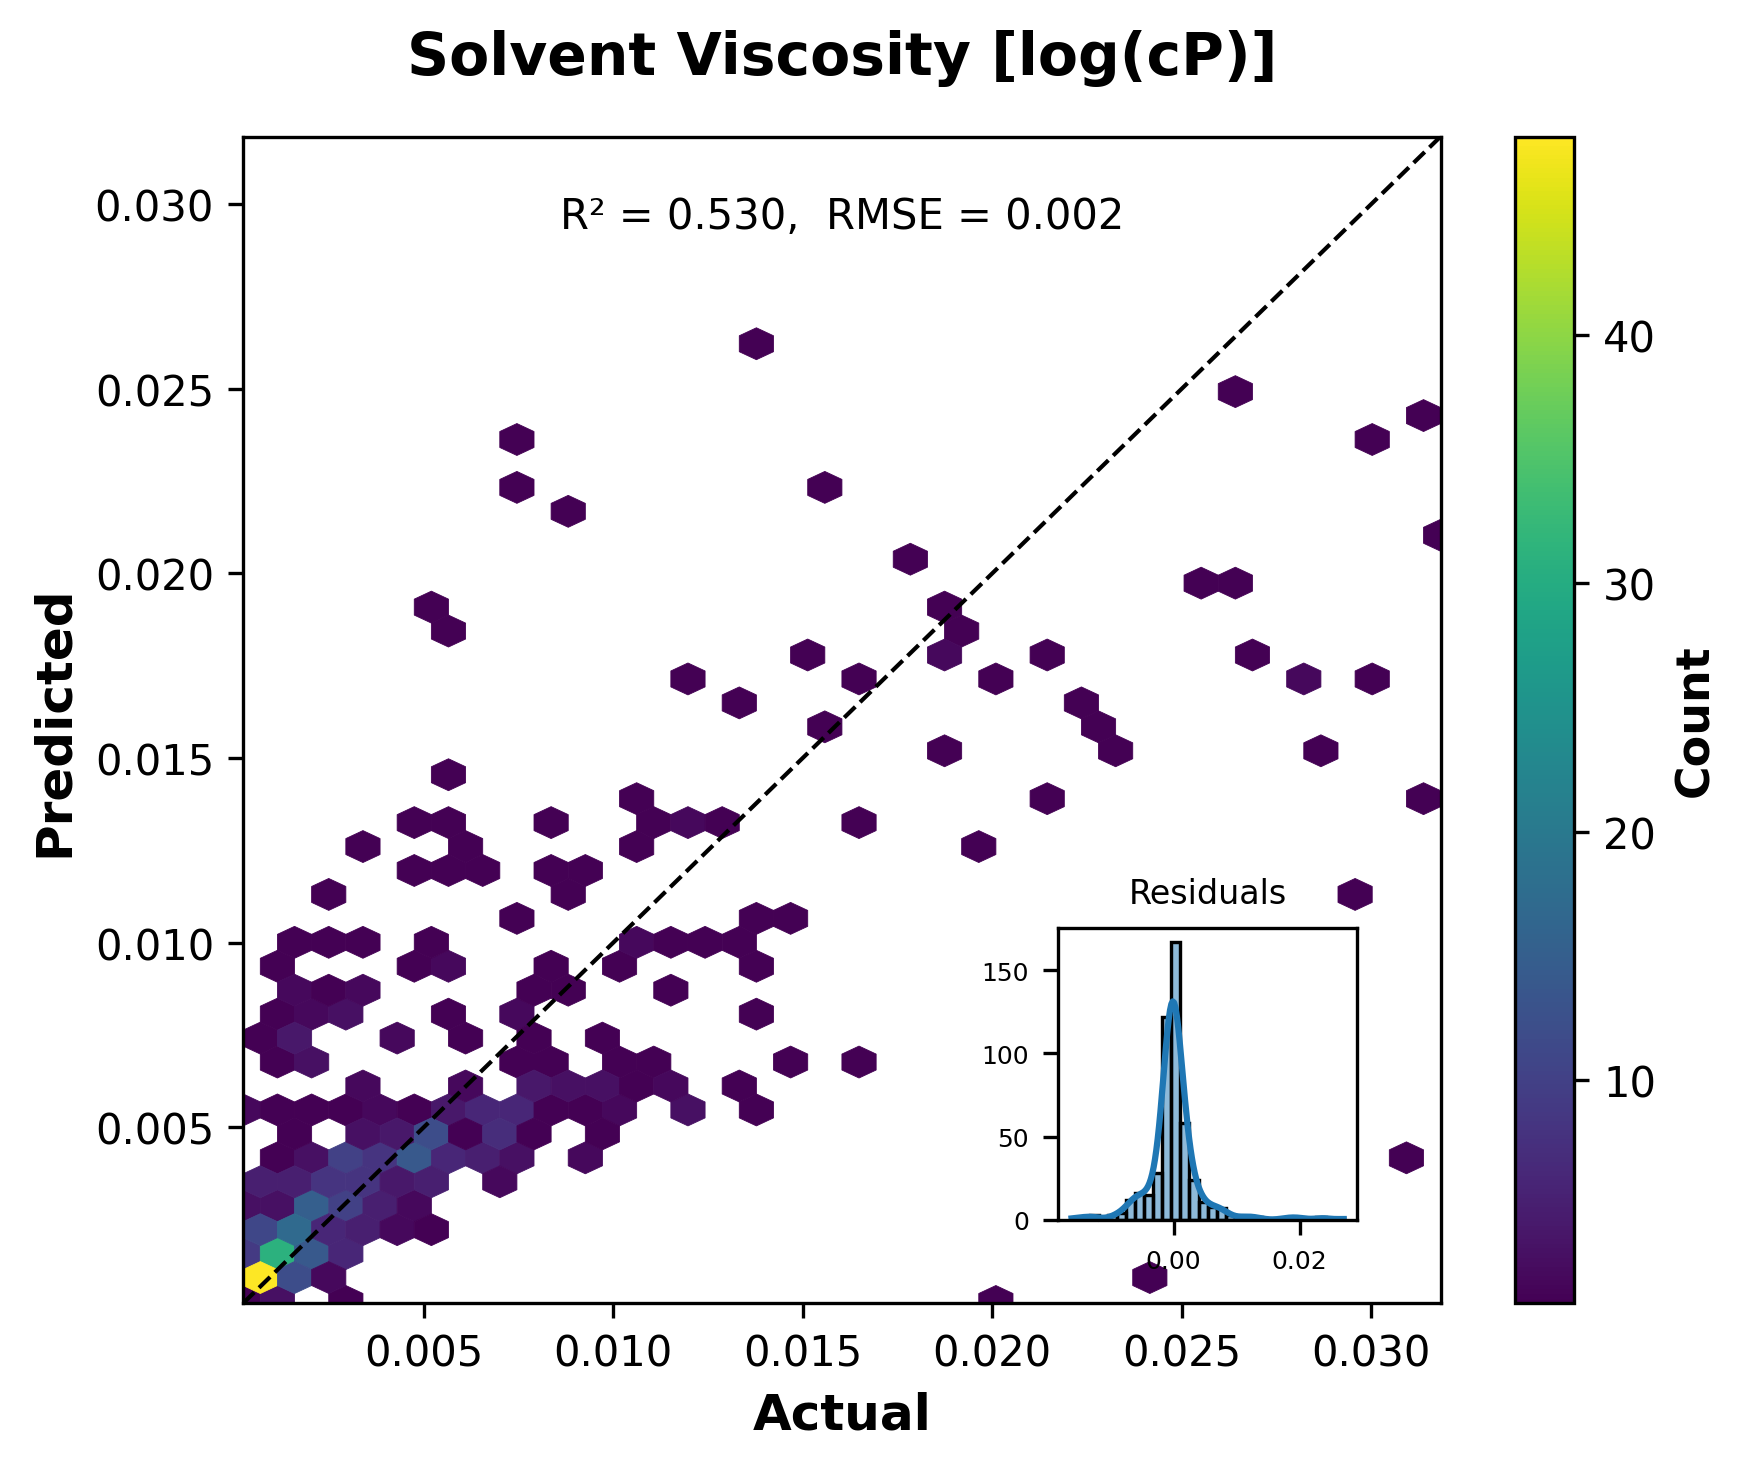

In [34]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_ood, y_pred_ood, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test_ood.min(), y_test_ood.max()], [y_test_ood.min(), y_test_ood.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
ax.set_xlim(left=y_test_ood.min(), right=y_test_ood.max())
ax.set_ylim(bottom=y_test_ood.min(), top=y_test_ood.max())

x_center = (y_test_ood.min() + y_test_ood.max()) / 2

# Title and axes labels
ax.set_title(f"Solvent Viscosity [log(cP)]", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {stats_ood[0]:.3f},  RMSE = {stats_ood[1]:.3f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
residuals = y_test_ood - y_pred_ood
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Viscosity_hexbin_density_plot_rf_ood.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\nandi\AppData\Local\Temp\ipykernel_20380\4073956215.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  ax.plot([y_test_rand.min(), y_test_rand.max()], [y_test_rand.min(), y_test_rand.max()], 'k--', linewidth=1, color='black')
C:\Users\nandi\AppData\Local\Temp\ipykernel_20380\4073956215.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


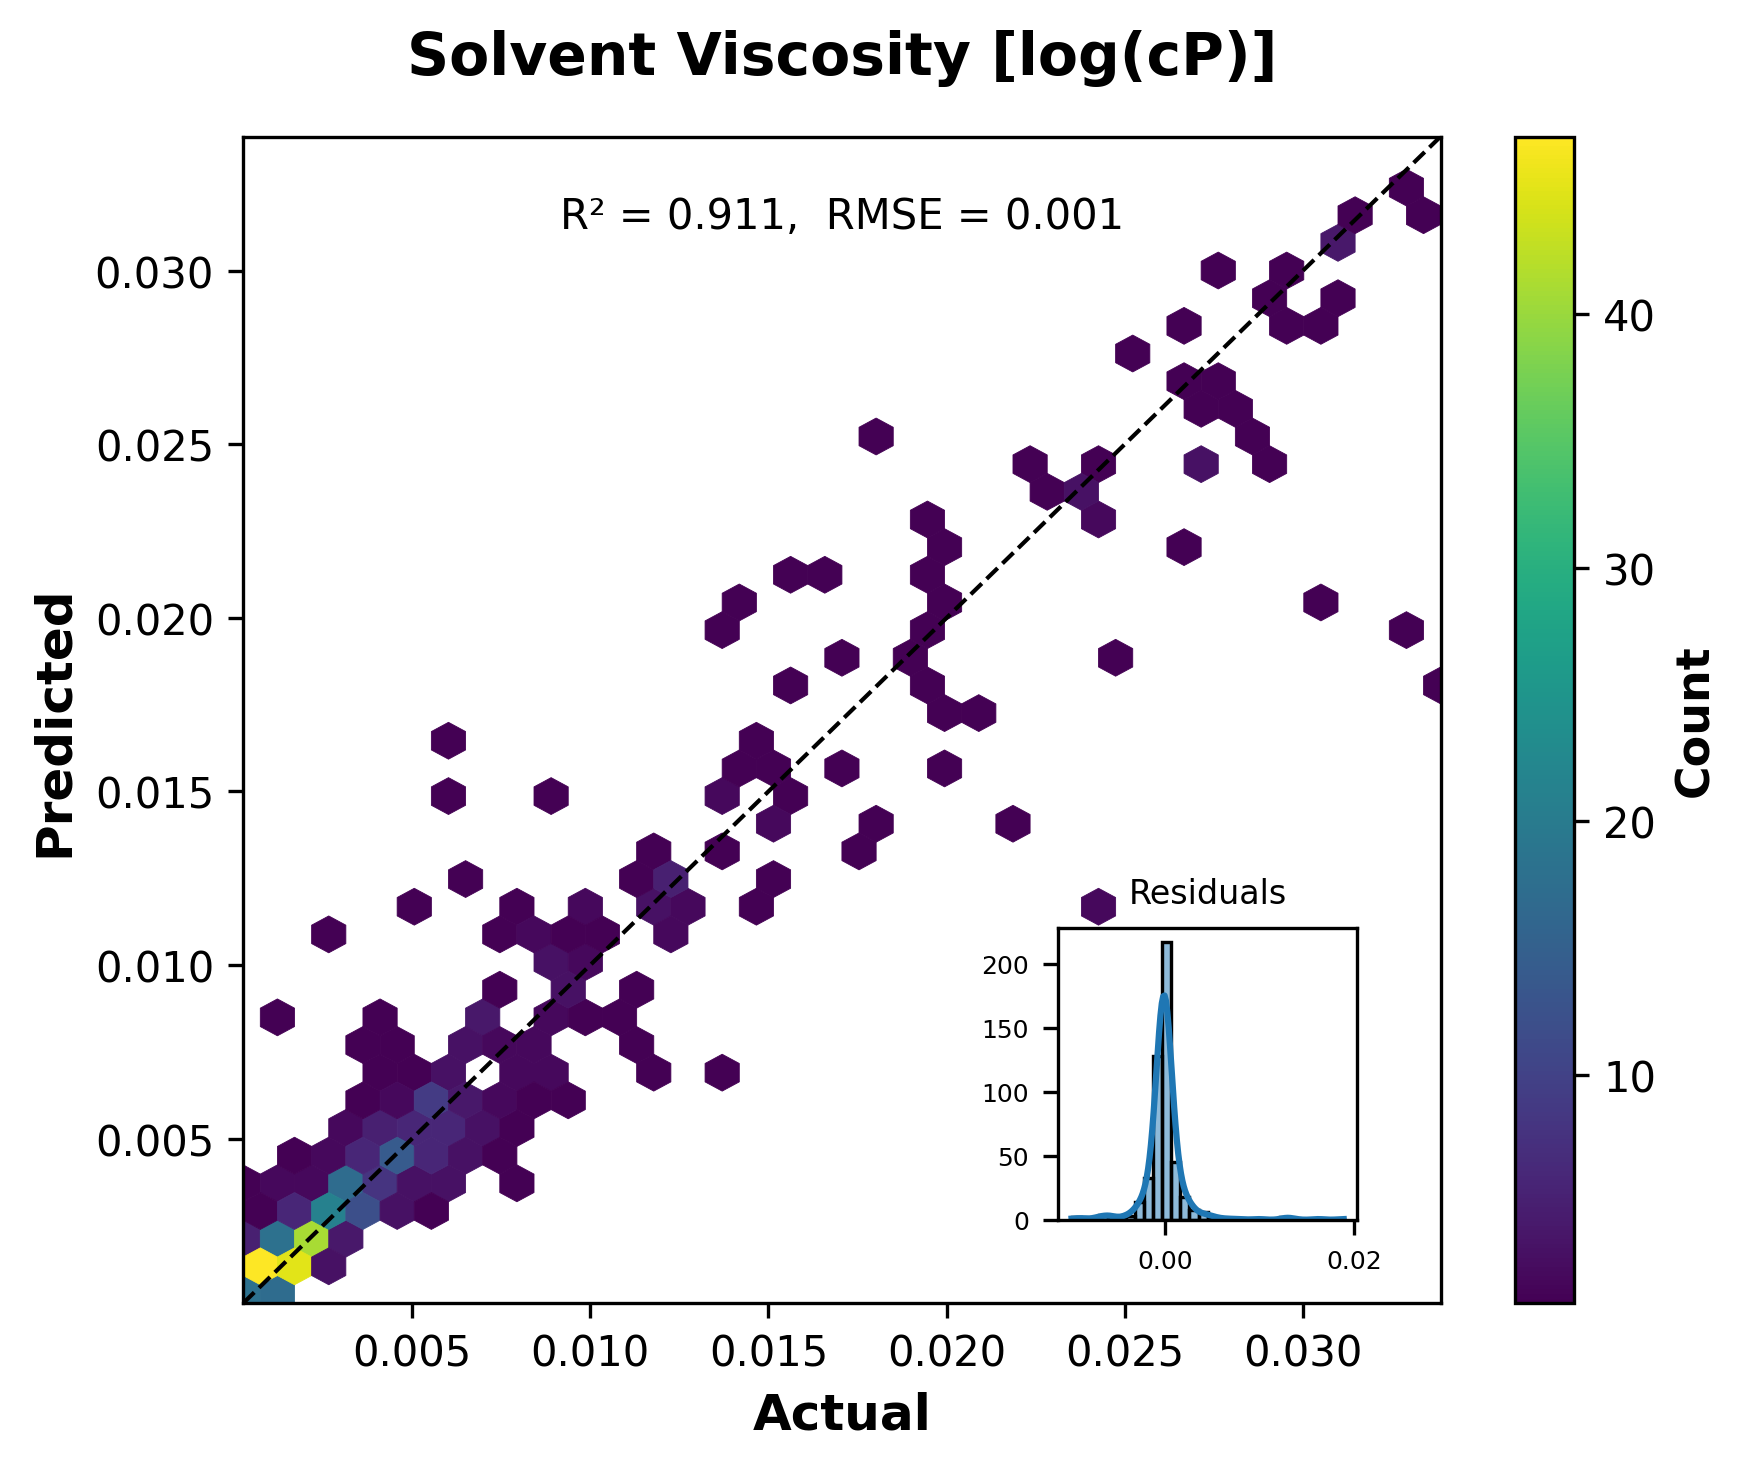

In [36]:
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Use point density plot (e.g. hexbin in matplotlib) instead of scatter plot for above to show the distribution information for the overlapped data points along with labeling the axes and adding a diagonal reference line.
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# Create hexbin plot with better visibility
hb = ax.hexbin(y_test_rand, y_pred_rand, gridsize=35, cmap='viridis', mincnt=1, edgecolors='face', linewidths=0.2)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Count', fontsize=11, fontweight='bold')

# Diagonal reference line
ax.plot([y_test_rand.min(), y_test_rand.max()], [y_test_rand.min(), y_test_rand.max()], 'k--', linewidth=1, color='black')

# remove 0 tick mark from x and y axis
ax.set_xticks([tick for tick in ax.get_xticks() if tick != 0])
ax.set_yticks([tick for tick in ax.get_yticks() if tick != 0])

# adjust x and y axis range (max 5 - as original scatter plot)
# diagonal line -make sure it spans the whole plot range.
ax.set_xlim(left=y_test_rand.min(), right=y_test_rand.max())
ax.set_ylim(bottom=y_test_rand.min(), top=y_test_rand.max())

x_center = (y_test_rand.min() + y_test_rand.max()) / 2

# Title and axes labels
ax.set_title(f"Solvent Viscosity [log(cP)]", 
             fontsize=14, fontweight='bold', pad=15)
# this should be inside the plot
y_top = ax.get_ylim()[1] - 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])
ax.text(x_center, y_top, f"R² = {stats_rand[0]:.3f},  RMSE = {stats_rand[1]:.3f}",
        fontsize=10, ha='center', va='top')
ax.set_xlabel("Actual", fontsize=12, fontweight='bold')
ax.set_ylabel("Predicted", fontsize=12, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)
# ➤ Inset residual plot
residuals = y_test_rand - y_pred_rand
inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower right', borderpad=2)
sns.histplot(residuals, bins=30, kde=True, ax=inset_ax)
inset_ax.set_title("Residuals", fontsize=8)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(labelsize=6)
# ax.legend(fontsize=11, loc='upper left')
# ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Viscosity_hexbin_density_plot_rf_ood.png", dpi=300, bbox_inches='tight')
plt.show()